<a href="https://colab.research.google.com/github/harimshin/data-science-portfolio/blob/main/ml_prediction_model_for_US_car_accidents.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### **Machine Learning Model to Predict the Severity of the Car Accidents**

**Objective**

Predict whether a traffic accident will become severe (Severity 3–4) using weather, road, temporal, and environmental information available at the time of the incident. Accurate predictions can support emergency response prioritization and traffic management.

**1. Data Preparation**

The dataset contains nearly 2.8 million accident records, making it computationally intensive for in-memory processing with pandas. PySpark was selected because it enables distributed data processing and provides scalable implementations of common machine learning algorithms.

Using PySpark allowed efficient execution of data cleaning, feature engineering, model training, and evaluation while maintaining a workflow that can be readily extended to larger datasets in production environments. It also demonstrates familiarity with big data technologies commonly used in industry.

In [1]:
%%bash
pip install pyspark

data_file=US_Accidents_Dec21_updated.csv
base_url=https://media.githubusercontent.com/media/harimshin
repo=public_dataset/main

if [[ ! -f ./${data_file} ]]; then
   wget ${base_url}/${repo}/${data_file} &>/dev/null
fi

In [2]:
# create spark context
from pyspark.sql import SparkSession
spark = SparkSession.builder.config("spark.driver.memory", "32g").getOrCreate()

In [3]:
# import car accidents dataset into a pyspark dataframe
df_raw = spark.read.option("header",True).csv("US_Accidents_Dec21_updated.csv")

In [4]:
df_raw.show(5)

+---+--------+-------------------+-------------------+------------------+------------------+------------------+------------------+-------------------+--------------------+------+-----------+----+----------+----------+-----+-------+-------+----------+------------+-------------------+--------------+-------------+-----------+------------+--------------+--------------+---------------+-----------------+-----------------+-------+-----+--------+--------+--------+-------+-------+----------+-------+-----+---------------+--------------+------------+--------------+--------------+-----------------+---------------------+
| ID|Severity|         Start_Time|           End_Time|         Start_Lat|         Start_Lng|           End_Lat|           End_Lng|       Distance(mi)|         Description|Number|     Street|Side|      City|    County|State|Zipcode|Country|  Timezone|Airport_Code|  Weather_Timestamp|Temperature(F)|Wind_Chill(F)|Humidity(%)|Pressure(in)|Visibility(mi)|Wind_Direction|Wind_Speed(mph)|P

In [5]:
from pyspark.sql.functions import count

# print the shape of the dataframe
print("Number of rows in the dataframe: ", df_raw.count())
print("Number of columns in the dataframe: ", len(df_raw.columns))

Number of rows in the dataframe:  2845342
Number of columns in the dataframe:  47


**2. Data Cleaning**

*2-1. Elimination of Variables*

Several variables were excluded prior to model training for the following reasons:

* Unique identifiers (e.g.,`ID`) do not contain predictive information.
* Features reflecting post-accident traffic impact (`End_Time`, `End_Lat`, `End_Lng`, `Distance(mi)`) were eliminated to avoid potential data leakage.
* Text-based fields (e.g., `Description`) were omitted because they require natural language processing, which was beyond the scope of this project.
* Geographic identifiers (`Start_Lat`, `Start_Lng`, `City`, `County`, `Airport_Code`, `Street`, `Zipcode`) with very high cardinality were removed to reduce model complexity and avoid overfitting.
* Variables that would not be available at prediction time or could introduce data leakage were excluded to ensure the model reflects a realistic deployment scenario.

In [6]:
drop_cols = ('ID', 'End_Time', 'Start_Lat', 'Start_Lng', 'End_Lat', 'End_Lng',
             'Distance(mi)', 'City', 'County', 'Airport_Code', 'Description',
             'Number', 'Street', 'Zipcode', 'Country', 'Weather_Timestamp')

df_clean = df_raw.drop(*drop_cols)

*2-2. Treatment of Missing Values*

Missing values were handled by removing incomplete observations rather than imputing them. Given the dataset contains approximately 2.8 million records, dropping rows with missing values resulted in only a modest reduction in sample size while preserving a sufficiently large training dataset.

This approach was chosen because:

* it avoids introducing bias through inaccurate imputation,
* it simplifies preprocessing,
* and it ensures that the models are trained using complete and reliable observations.

For datasets with substantially fewer observations, more sophisticated imputation techniques would be preferable.

In [7]:
df_clean = df_clean.na.drop()

In [8]:
print("Number of rows in the dataframe: ", df_clean.count())
print("Number of columns in the dataframe: ", len(df_clean.columns))

Number of rows in the dataframe:  2207326
Number of columns in the dataframe:  31


*2-3. Feature Engineering and Data Transformation*

The raw accident dataset was transformed into an analysis-ready format by extracting temporal features(e.g.,`Day_of_Week`), converting weather variables(e.g.,`Tempertature(F)`) to appropriate numeric types, standardizing `Wind_Direction` categories, and grouping detailed `Weather_Condition` descriptions into broader interpretable categories. These feature-engineering steps improved data consistency, reduced category sparsity, and facilitated subsequent exploratory and modeling analyses.


In [9]:
from pyspark.sql.functions import col, when, date_format, to_date, hour
from pyspark.sql.types import FloatType, BooleanType, StringType

df_transformed = (
    df_clean
      .withColumn("Day_of_Week", date_format(to_date("Start_Time"), "E"))
      .withColumn("Hour", hour("Start_Time").cast(StringType()))
      .withColumn("Start_Time", to_date("Start_Time"))
      .withColumn("Temperature(F)", col("Temperature(F)").cast(FloatType()))
      .withColumn("Wind_Chill(F)", col("Wind_Chill(F)").cast(FloatType()))
      .withColumn("Humidity(%)", col("Humidity(%)").cast(FloatType()))
      .withColumn("Pressure(in)", col("Pressure(in)").cast(FloatType()))
      .withColumn("Visibility(mi)", col("Visibility(mi)").cast(FloatType()))
      .withColumn("Wind_Direction",
          when(df_clean.Wind_Direction == 'North', "N")
        .when(df_clean.Wind_Direction == "South", "S")
        .when(df_clean.Wind_Direction == "East", "E")
        .when(df_clean.Wind_Direction == "West", "W")
        .when(df_clean.Wind_Direction ==  "Variable", "VAR")
        .otherwise(df_clean.Wind_Direction))
      .withColumn("Wind_Speed(mph)", col("Wind_Speed(mph)").cast(FloatType()))
      .withColumn("Precipitation(in)", col("Precipitation(in)").cast(FloatType()))
      .withColumn("Weather_Group",
          when(col("Weather_Condition").isNull()
            | (col("Weather_Condition") == "N/A Precipitation"),
               "Unknown")
        .when(col("Weather_Condition").contains("Tornado")
            | col("Weather_Condition").contains("Funnel")
            | col("Weather_Condition").contains("Squalls")
            | col("Weather_Condition").contains("Hail"),
              "Severe")
        .when(col("Weather_Condition").contains("Snow")
            | col("Weather_Condition").contains("Sleet")
            | col("Weather_Condition").contains("Wintry Mix")
            | col("Weather_Condition").contains("Ice Pellets"),
              "Snow")
        .when(col("Weather_Condition").contains("Thunder")
            | col("Weather_Condition").contains("T-Storm"),
              "Thunderstorm")
        .when(col("Weather_Condition").contains("Rain")
            | col("Weather_Condition").contains("Drizzle")
            | col("Weather_Condition").contains("Freezing"),
              "Rain")
        .when(col("Weather_Condition").contains("Fog")
            | col("Weather_Condition").contains("Mist")
            | col("Weather_Condition").contains("Haze")
            | col("Weather_Condition").contains("Smoke")
            | col("Weather_Condition").contains("Sand")
            | col("Weather_Condition").contains("Ash"),
              "Fog_Dust")
        .when(col("Weather_Condition").contains("Clear")
            | col("Weather_Condition").contains("Fair"),
              "Clear")
        .when(col("Weather_Condition").contains("Cloud")
            | (col("Weather_Condition") == "Overcast"),
              "Cloudy")
        .otherwise("Other"))
)

We drop the original `Start_Time` and `Weather_Condition` columns because the relevant information they contain has already been extracted into more useful, model-ready features: `Start_Time` was decomposed into `Day_of_Week` and `Hour`, and `Weather_Condition` was consolidated into `Weather_Group`. Keeping the raw columns alongside their derived features would be redundant and could introduce noise or leakage (e.g., high-cardinality raw text values with no added predictive value beyond what's already captured). Additionally, since `Weather_Condition` contains missing values, we drop rows where the derived `Weather_Group` is "Unknown" — resulting from the raw `Weather_Condition` being missing/unrecorded — rather than trying to impute a suitable weather category from insufficient information.

In [10]:
df_transformed = (
    df_transformed
      .drop('Start_Time', 'Weather_Condition')
      .filter(col("Weather_Group") != "Unknown")
)

n_rows_dropped = df_clean.count() - df_transformed.count()

print(f"Number of dropped rows: {n_rows_dropped}")
print(f"Number of rows in the new dataframe: {df_transformed.count()}")
print(f"Number of columns in the new dataframe: {len(df_transformed.columns)}")

Number of dropped rows: 944
Number of rows in the new dataframe: 2206382
Number of columns in the new dataframe: 32


*2-4. Simplification of Target Variable*

The US Accidents dataset defines accident severity as an ordinal variable ranging from 1 (least severe) to 4 (most severe). The severity score reflects the impact of the accident on traffic rather than the medical severity of injuries.
To simplify the classification problem, Severity levels 1 and 2 were grouped as non-severe accidents(`Severity` = 0), while Severity levels 3 and 4 were grouped as severe accidents(`Severity` = 1). Since the original severity variable is ordinal and represents increasing levels of traffic impact, this transformation preserves the distinction between lower- and higher-impact accidents while producing a binary target suitable for classification models.

In [11]:
df_transformed = (
    df_transformed
      .withColumn("Severity",
                  when(df_clean.Severity < 3, 0)
                  .when(df_clean.Severity >= 3, 1))
)

In [12]:
df_transformed.printSchema()

root
 |-- Severity: integer (nullable = true)
 |-- Side: string (nullable = true)
 |-- State: string (nullable = true)
 |-- Timezone: string (nullable = true)
 |-- Temperature(F): float (nullable = true)
 |-- Wind_Chill(F): float (nullable = true)
 |-- Humidity(%): float (nullable = true)
 |-- Pressure(in): float (nullable = true)
 |-- Visibility(mi): float (nullable = true)
 |-- Wind_Direction: string (nullable = true)
 |-- Wind_Speed(mph): float (nullable = true)
 |-- Precipitation(in): float (nullable = true)
 |-- Amenity: string (nullable = true)
 |-- Bump: string (nullable = true)
 |-- Crossing: string (nullable = true)
 |-- Give_Way: string (nullable = true)
 |-- Junction: string (nullable = true)
 |-- No_Exit: string (nullable = true)
 |-- Railway: string (nullable = true)
 |-- Roundabout: string (nullable = true)
 |-- Station: string (nullable = true)
 |-- Stop: string (nullable = true)
 |-- Traffic_Calming: string (nullable = true)
 |-- Traffic_Signal: string (nullable = true)

In [13]:
df_transformed.show(5)

+--------+----+-----+----------+--------------+-------------+-----------+------------+--------------+--------------+---------------+-----------------+-------+-----+--------+--------+--------+-------+-------+----------+-------+-----+---------------+--------------+------------+--------------+--------------+-----------------+---------------------+-----------+----+-------------+
|Severity|Side|State|  Timezone|Temperature(F)|Wind_Chill(F)|Humidity(%)|Pressure(in)|Visibility(mi)|Wind_Direction|Wind_Speed(mph)|Precipitation(in)|Amenity| Bump|Crossing|Give_Way|Junction|No_Exit|Railway|Roundabout|Station| Stop|Traffic_Calming|Traffic_Signal|Turning_Loop|Sunrise_Sunset|Civil_Twilight|Nautical_Twilight|Astronomical_Twilight|Day_of_Week|Hour|Weather_Group|
+--------+----+-----+----------+--------------+-------------+-----------+------------+--------------+--------------+---------------+-----------------+-------+-----+--------+--------+--------+-------+-------+----------+-------+-----+------------

In [14]:
target_col = "Severity"

# numerical
weather_cols = [
    'Temperature(F)', 'Wind_Chill(F)', 'Humidity(%)', 'Pressure(in)',
    'Visibility(mi)', 'Wind_Speed(mph)', 'Precipitation(in)'
]

# categorical
other_cat_cols = [
    'State', 'Timezone', 'Day_of_Week', 'Hour', 'Wind_Direction',
    'Weather_Group'
]

road_cols = [
    'Amenity', 'Bump', 'Crossing', 'Give_Way', 'Junction', 'No_Exit',
    'Railway', 'Roundabout', 'Station', 'Stop', 'Traffic_Calming',
    'Traffic_Signal'
]

light_cols = [
    'Sunrise_Sunset', 'Civil_Twilight',
    'Nautical_Twilight', 'Astronomical_Twilight'
]

# assign features to groups to build model later
numeric_cols = weather_cols
categorical_cols = other_cat_cols + road_cols + light_cols

**3. Exploratory Data Analysis (EDA)**

*3-1. Data Sampling for Exploratory Data Analysis*

A stratified random sample was created to support efficient exploratory data analysis while preserving the class distribution of accident severity. Five percent of observations from each severity class were sampled using a fixed random seed (`seed=42`). The sampled data were then converted from a PySpark DataFrame to a Pandas DataFrame, enabling the use of Python visualization libraries such as Matplotlib for generating plots and performing interactive exploratory analyses more efficiently on a manageable subset of the data.


In [15]:
from random import sample

df_sampled = df_transformed.sampleBy(
    "Severity",
    fractions={0: 0.10, 1: 0.10},
    seed=42
)

df_eda = df_sampled.toPandas()

# df_eda = df_transformed.toPandas()

*3-2. Class Distribution of Target Outcome*

In [16]:
from pyspark.sql.functions import col, round
import matplotlib.pyplot as plt


def plot_distribution_percentage(
    df,
    group_col,
    title="Distribution",
    xlabel=None,
    figsize=(3, 2),
    dpi=200
):
    """
    Plot count and percentage distribution of a categorical variable.

    Parameters
    ----------
    df : pyspark.sql.DataFrame
        Input Spark DataFrame.
    group_col : str
        Column name to summarize.
    title : str
        Plot title.
    xlabel : str
        X-axis label.
    figsize : tuple
        Figure size.
    dpi : int
        Figure resolution.
    """

    total = df.count()
    summary = (
        df
        .groupBy(group_col)
        .count()
        .withColumn(
            "Percentage",
            round(col("count") / total * 100, 2)
        )
        .orderBy(col(group_col).asc())
    )
    summary_pd = summary.toPandas()

    fig, ax = plt.subplots(figsize=figsize, dpi=dpi)
    bars = ax.bar(
        summary_pd[group_col].astype(str),
        summary_pd["count"]
    )

    for bar, count, pct in zip(
        bars,
        summary_pd["count"],
        summary_pd["Percentage"]
    ):
        height = bar.get_height()
        ax.annotate(
            f"{count:,}\n({pct}%)",
            xy=(bar.get_x() + bar.get_width() / 2, height),
            xytext=(0, 1),
            textcoords="offset points",
            ha="center",
            va="bottom",
            fontsize=5
        )

    ax.set_title(title, fontsize=6)
    ax.set_xlabel(xlabel if xlabel else group_col, fontsize=5)
    ax.set_ylabel("Count", fontsize=5)
    ax.tick_params(
        axis="both",
        labelsize=5,
        length=2
    )
    ax.set_ylim(
        0,
        summary_pd["count"].max() * 1.25
    )
    ax.yaxis.get_offset_text().set_fontsize(5)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    plt.tight_layout()
    plt.show()

    return summary_pd

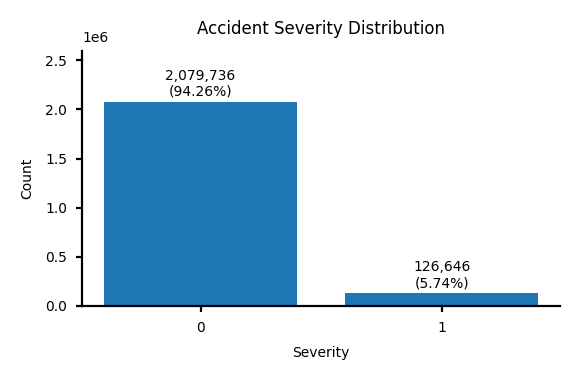

In [17]:
target_dist = plot_distribution_percentage(
    df_transformed,
    group_col=target_col,
    title="Accident Severity Distribution",
    xlabel=target_col
)

The plot shows a strong class imbalance — Severity 0 makes up 94.26% of records (2,080,632) while Severity 1 is just 5.74% (126,694), a ratio of roughly 16:1. This matters because a model could reach ~94% accuracy simply by always predicting Severity 0, without actually learning to distinguish severe accidents. We'll need to address this later with SMOTE on the training set (applied after the train/test split to avoid data leakage) so the model can learn the minority class properly.

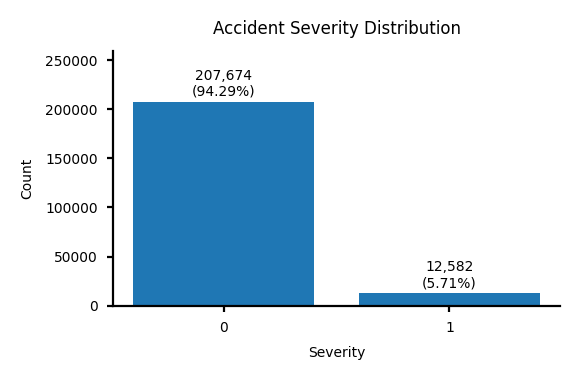

In [18]:
sampled_target_dist = plot_distribution_percentage(
    df_sampled,
    group_col=target_col,
    title="Accident Severity Distribution",
    xlabel=target_col
)

The 10% sampled dataset retains nearly the same target class distribution as the original dataset (approximately 94% non-severe and 6% severe accidents), indicating that the sampling process successfully preserved the original class imbalance.

*3-3. Continuous Features Effects on Target Outcome*

3-3-a. Correlation Heatmap

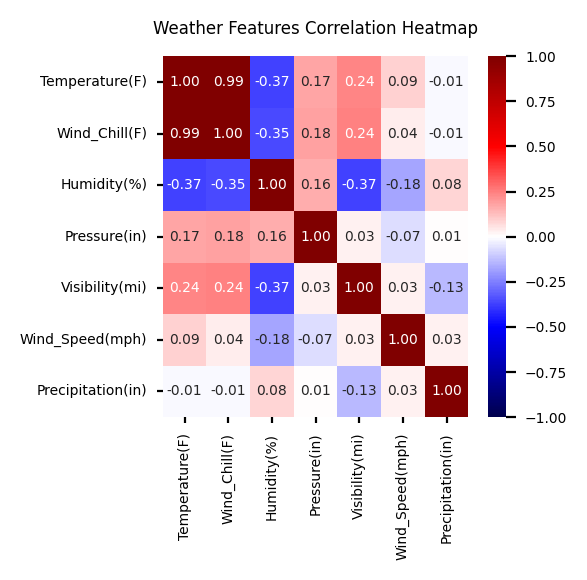

In [19]:
import seaborn as sns
import warnings


# visualize the correlation between weather-related features

weather_df = df_eda[weather_cols]

fig, ax = plt.subplots(figsize=(3, 3), dpi=200)

weather_corr = sns.heatmap(
    weather_df.corr(),
    vmin=-1,
    vmax=1,
    annot=True,
    cmap="seismic",
    fmt=".2f",
    annot_kws={"fontsize": 5},
    ax=ax
)

weather_corr.set_title(
    'Weather Features Correlation Heatmap',
    fontdict={'fontsize': 6},
    pad=8
)
ax.tick_params(axis="both", labelsize=5, length=2)

cbar = weather_corr.collections[0].colorbar
cbar.ax.tick_params(labelsize=5)

plt.tight_layout()
plt.show()

The correlation analysis shows a very strong positive correlation between `Temperature(F)` and `Wind_Chill(F)` (r = 0.99), indicating that these two variables capture similar temperature-related information. `Humidity(%)` shows moderate negative correlations with `Temperature(F)` (r = -0.37), `Wind_Chill(F)` (r = -0.35), and `Visibility(mi)` (r = -0.37), suggesting that higher humidity is generally associated with lower temperatures and reduced visibility. `Visibility(mi)` also has a weak positive correlation with `Temperature(F)` (r = 0.24).

[Note]
Because of the r = 0.99 correlation, `Temperature(F)` and `Wind_Chill(F)` will need to be reconciled before final modeling — including both risks severe multicollinearity.

3-3-b. Rate Lift Plots

Before evaluating how any feature affects severity, we need a reference point to compare against — this line computes the overall (unconditional) severity rate across the full dataset. Since the target is binary, its mean directly gives the baseline probability $P(Y=1)$, i.e., the proportion of severe cases regardless of any feature. This baseline is the anchor for every severity-lift calculation that follows, computed as:

$Severity Rate Lift = P(Y=1 | X) − P(Y=1)$

In other words, it's the difference between the severity rate conditional on a feature value (or group) and this overall baseline rate, which tells us whether that condition increases or decreases severity risk relative to the average case.

In [21]:
baseline_rate = df_eda[target_col].mean() * 100
print(f"Baseline rate: {baseline_rate:.1f}%")

Baseline rate: 5.7%


In [22]:
from sklearn.tree import DecisionTreeClassifier

def _get_tree_bin_edges(x, y, n_bins, min_samples_leaf=0.02):
    """
    Fit a shallow decision tree on a single feature to find split
    points that best separate the target. Returns sorted bin edges
    (including -inf and inf) derived from the tree's thresholds.
    """

    tree = DecisionTreeClassifier(
        max_leaf_nodes=n_bins,
        min_samples_leaf=min_samples_leaf,
        random_state=0
    )

    tree.fit(x.values.reshape(-1, 1), y.values)

    thresholds = tree.tree_.threshold[tree.tree_.feature != -2]

    edges = sorted(thresholds)

    edges = [-np.inf] + edges + [np.inf]

    return edges

In [23]:
def _get_bin_edges(x, y, n_bins, min_samples_leaf, spike_frac_threshold=0.2):
    """
    Build bin edges for a possibly zero-/spike-inflated feature.

    If a single value accounts for a large share of observations
    (e.g. zero-inflated features), that value is carved out as its
    own bin first. The decision tree is then fit only on the
    remaining data, so its splits aren't "wasted" rediscovering
    the spike and instead capture structure in the informative range.
    """

    value_counts = x.value_counts(normalize=True)

    top_value = value_counts.idxmax()

    top_frac = value_counts.max()

    if top_frac >= spike_frac_threshold:

        is_spike = x == top_value

        edges = _get_tree_bin_edges(
            x[~is_spike],
            y[~is_spike],
            n_bins=n_bins - 1,
            min_samples_leaf=min_samples_leaf
        )

        # replace the -inf/inf boundary touching the spike side
        # with the spike value itself, so the spike becomes its
        # own clean bin
        if top_value <= x[~is_spike].median():
            edges[0] = top_value
        else:
            edges[-1] = top_value

        edges = sorted(set(edges) | {top_value})

    else:

        edges = _get_tree_bin_edges(
            x,
            y,
            n_bins=n_bins,
            min_samples_leaf=min_samples_leaf
        )

    return edges

In [24]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import chi2_contingency
import matplotlib.patches as mpatches

def plot_continuous_feature_impact(
    df,
    feature,
    target_col,
    baseline_rate,
    n_bins=10,
    alpha_sig=0.05,
    title=None,
    figsize=(3, 3),
    height_ratios=[2,1],
    dpi=200,
    x_rotation=0,
    legend_loc="upper right",
    count_log=False,
    min_samples_leaf=0.02
):
    """
    Compare outcome rates across bins of a continuous feature.

    Bins are derived from a shallow decision tree trained to
    separate `target_col`, so bin edges reflect points where the
    feature actually predicts the outcome differently -- rather
    than arbitrary quantile cutpoints.

    Top panel:
        Rate lift (percentage points) relative to the baseline rate.

    Bottom panel:
        Sample count within each bin.

    Bar transparency indicates statistical significance
    (chi-square test: bin vs. all remaining observations).
    """

    data = df[[feature, target_col]].copy()

    # --------------------------------------------------
    # Create bins (supervised, via decision tree splits)
    # --------------------------------------------------

    edges = _get_bin_edges(
        data[feature],
        data[target_col],
        n_bins=n_bins,
        min_samples_leaf=min_samples_leaf
    )

    data['bin'] = pd.cut(data[feature], bins=edges, include_lowest=True)

    results = []

    for b in data["bin"].cat.categories:

        in_bin = data["bin"] == b

        sub = data.loc[in_bin]

        n = len(sub)

        if n == 0:
            continue

        rate = sub[target_col].mean() * 100
        diff = rate - baseline_rate

        ct = pd.crosstab(
            in_bin,
            data[target_col]
        )

        p_value = (
            chi2_contingency(ct)[1]
            if ct.shape == (2, 2)
            else np.nan
        )

        # Label from actual observed feature range in this bin
        label = f"({sub[feature].min():.3g}, {sub[feature].max():.3g}]"

        results.append({
            "bin": b,
            "label": label,
            "lift": diff,
            "rate": rate,
            "count": n,
            "p_value": p_value,
            "mean_value": sub[feature].mean()
        })

    res_df = pd.DataFrame(results)

    # --------------------------------------------------
    # Figure
    # --------------------------------------------------

    fig, axes = plt.subplots(
        2,
        1,
        figsize=figsize,
        dpi=dpi,
        sharex=True,
        gridspec_kw={
            "height_ratios": height_ratios,
            "hspace": 0.08
        }
    )

    # ==================================================
    # Panel 1
    # ==================================================

    ax1 = axes[0]

    colors = np.where(
        res_df["lift"] > 0,
        "#d62728",
        "#1f77b4"
    )

    bars = ax1.bar(
        res_df["label"],
        res_df["lift"],
        color=colors
    )

    is_sig = res_df["p_value"] < alpha_sig

    for bar, sig in zip(bars, is_sig):
        bar.set_alpha(0.85 if sig else 0.35)

    ax1.axhline(0, color="black", linewidth=0.8)
    ax1.set_ylabel(f"{target_col} Rate Lift\n(pp)", fontsize=5)
    ax1.set_title(
        title or f"Impact of {feature} on {target_col}",
        fontsize=6,
        pad=8
    )

    ax1.text(
        0.5,
        1.01,
        f"Baseline rate = {baseline_rate:.1f}%",
        transform=ax1.transAxes,
        ha="center",
        va="bottom",
        fontsize=5,
        color="gray"
    )

    ax1.tick_params(axis="both", labelsize=5)

    ax1.legend(
        handles=[
            mpatches.Patch(
                color="gray",
                alpha=0.85,
                label=f"p < {alpha_sig}"
            ),
            mpatches.Patch(
                color="gray",
                alpha=0.35,
                label=f"p ≥ {alpha_sig}"
            )
        ],
        fontsize=5,
        loc=legend_loc,
        frameon=False
    )

    ax1.margins(y=0.02)

    # ==================================================
    # Panel 2
    # ==================================================

    ax2 = axes[1]

    ax2.bar(
        res_df["label"],
        res_df["count"],
        color="#4C72B0",
        alpha=0.8
    )

    ax2.set_xlabel(feature, fontsize=5)
    ax2.set_ylabel("Count", fontsize=5)
    ax2.tick_params(axis="both", labelsize=5)
    ax2.margins(y=0.02)
    plt.setp(
        ax2.get_xticklabels(),
        rotation=x_rotation
    )

    if count_log:
        ax2.set_yscale("log")

    # plt.tight_layout()

    return res_df

* Temperature

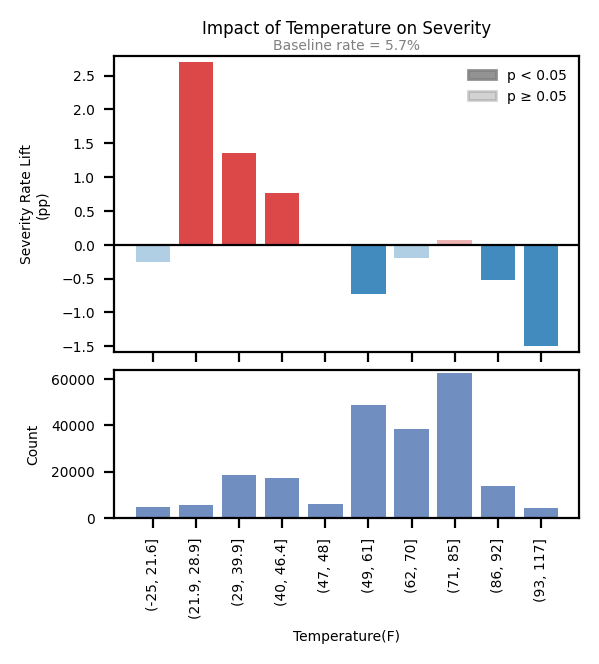

In [25]:
temperature_result = plot_continuous_feature_impact(
    df=df_eda,
    feature="Temperature(F)",
    target_col="Severity",
    baseline_rate=baseline_rate,
    n_bins=10,
    title="Impact of Temperature on Severity",
    x_rotation=90
)

Accident severity is highest under cold temperatures, remains relatively stable across moderate temperatures, and decreases under the hottest conditions, suggesting colder weather is associated with more severe crashes. This pattern is likely due to hazardous road conditions, such as ice, snow, and reduced visibility, which increase the likelihood of more severe accidents during colder weather.

* Wind Chill

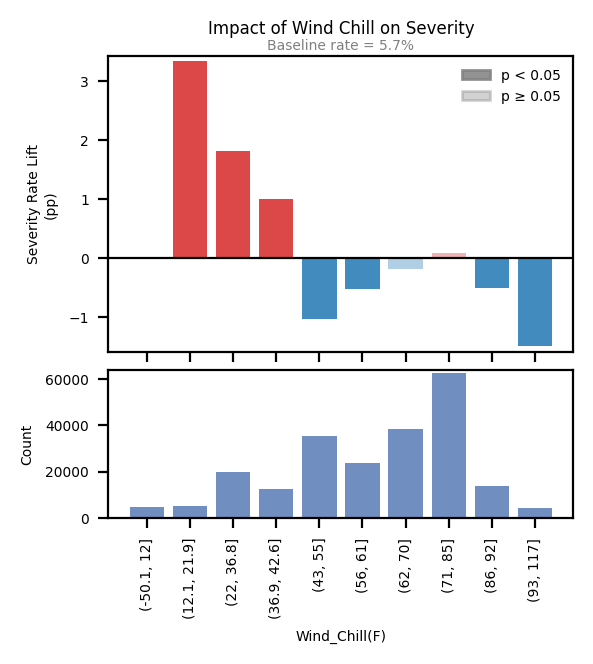

In [26]:
wind_chill_result = plot_continuous_feature_impact(
    df=df_eda,
    feature="Wind_Chill(F)",
    target_col="Severity",
    baseline_rate=baseline_rate,
    n_bins=10,
    title="Impact of Wind Chill on Severity",
    x_rotation=90
)

Wind chill exhibits the same overall pattern as temperature, with accident severity highest under cold conditions, relatively stable at moderate levels, and lower under the hottest conditions. This stronger contrast at colder temperatures likely reflects the combined effects of low temperatures and wind, which increase hazards such as icy roads, reduced visibility, and decreased vehicle traction, making wind chill a more informative predictor than temperature alone.

* Humidity

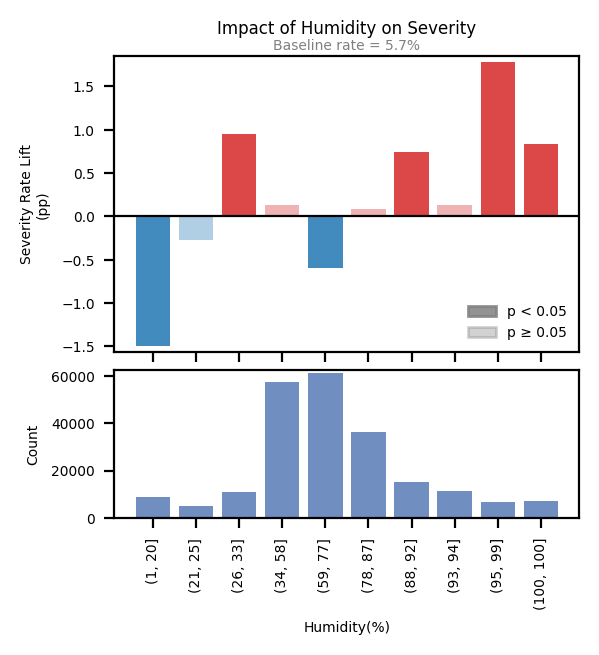

In [27]:
humidity_result = plot_continuous_feature_impact(
    df=df_eda,
    feature="Humidity(%)",
    target_col="Severity",
    baseline_rate=baseline_rate,
    n_bins=10,
    title="Impact of Humidity on Severity",
    x_rotation=90,
    legend_loc="lower right"
)

Accident severity is generally higher under very humid conditions, while moderate humidity levels are associated with relatively lower severity. This pattern likely reflects the impact of rain, fog, and reduced road traction under high humidity, whereas the increased severity observed at very low humidity may be driven by distinct weather conditions such as dust or unusually dry environments rather than humidity itself.

* Visibility

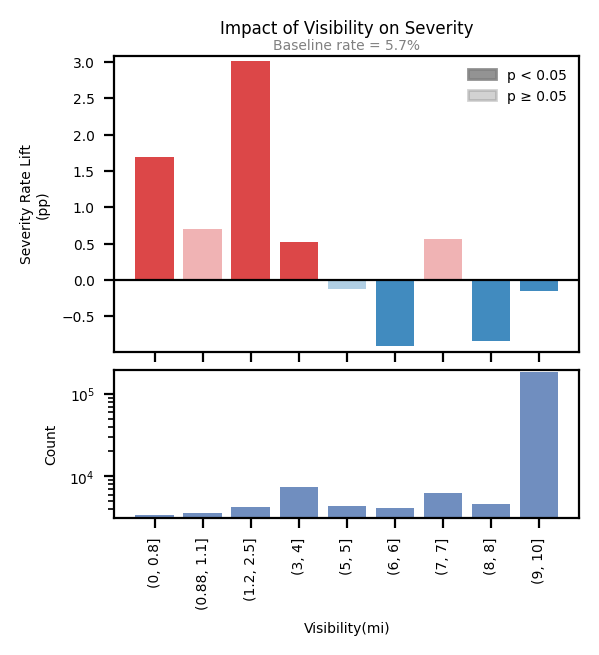

In [28]:
visibility_result = plot_continuous_feature_impact(
    df=df_eda,
    feature="Visibility(mi)",
    target_col="Severity",
    baseline_rate=baseline_rate,
    n_bins=10,
    title="Impact of Visibility on Severity",
    x_rotation=90,
    legend_loc="upper right",
    count_log=True
)

Accident severity is generally higher under poor visibility and lower under good visibility, indicating that reduced visibility is associated with more severe crashes. This pattern is likely due to drivers having less time to detect and react to hazards in conditions such as fog or heavy precipitation, although results at intermediate visibility levels should be interpreted cautiously because they are based on relatively fewer observations.


* Wind Speed

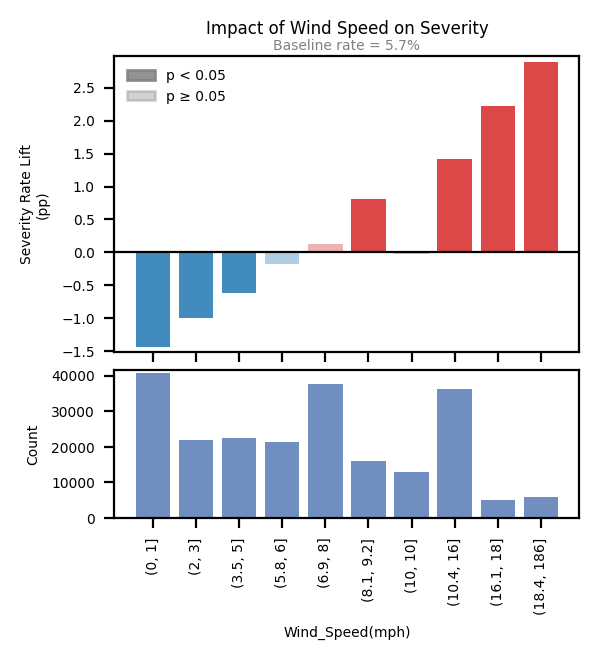

In [29]:
wind_speed_result = plot_continuous_feature_impact(
    df=df_eda,
    feature="Wind_Speed(mph)",
    target_col="Severity",
    baseline_rate=baseline_rate,
    n_bins=10,
    title="Impact of Wind Speed on Severity",
    x_rotation=90,
    legend_loc="upper left"
)

Accident severity generally increases as wind speed rises, suggesting that stronger winds are associated with more severe crashes. This pattern is likely due to reduced vehicle stability, increased debris on roadways, and the amplification of other adverse weather conditions, although the highest wind speed ranges contain relatively fewer observations.


* Precipitation

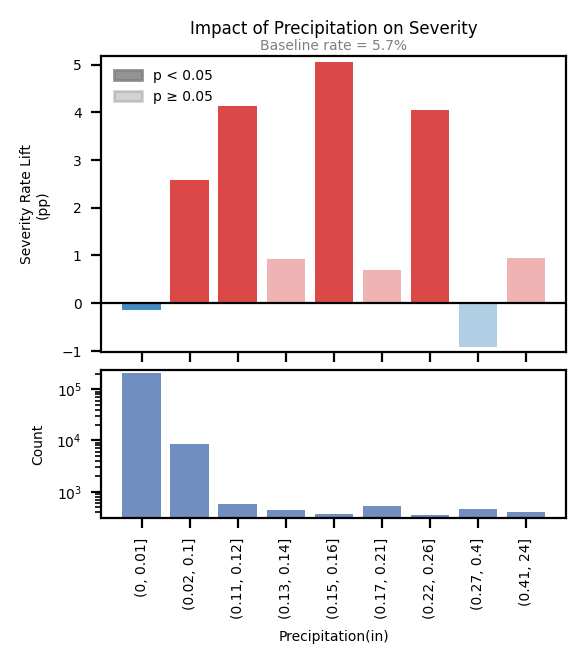

In [30]:
precipitation_result = plot_continuous_feature_impact(
    df=df_eda,
    feature="Precipitation(in)",
    target_col="Severity",
    baseline_rate=baseline_rate,
    n_bins=10,
    title="Impact of Precipitation on Severity",
    x_rotation=90,
    legend_loc="upper left",
    count_log=True
)

Accident severity is generally higher when precipitation is present than under dry conditions, suggesting that even light rainfall is associated with more severe crashes. This pattern is likely driven by reduced road traction and visibility on wet surfaces, although the relationship at heavier precipitation levels is less consistent because those conditions are relatively rare.


*3-4. Categorical/Binary Features*

3-4-a. Cramér's V

Cramér's V is used to detect associations among categorical features and identify potential multicollinearity before model training. Unlike Pearson correlation, which is designed for continuous variables and linear relationships, Cramér's V is based on the chi-square statistic and ranges from 0 to 1, with higher values indicating stronger overlap between categorical variables.

In [31]:
"""
Check correlation / multicollinearity between categorical features:
Timezone, Side, State, Weather_Group (adjust column names as needed).

0.0-0.1 : negligible association
0.1-0.3 : weak
0.3-0.5 : moderate
0.5+    : strong (redundant — consider dropping one)
"""

import pandas as pd
import numpy as np
from scipy.stats import chi2_contingency
import matplotlib.pyplot as plt
import seaborn as sns

def cramers_v(x: pd.Series, y: pd.Series) -> float:
    """Bias-corrected Cramer's V between two categorical series."""
    confusion_matrix = pd.crosstab(x, y)
    chi2 = chi2_contingency(confusion_matrix, correction=False)[0]
    n = confusion_matrix.sum().sum()
    phi2 = chi2 / n
    r, k = confusion_matrix.shape

    # Bias correction (Bergsma 2013)
    phi2_corr = max(0, phi2 - ((k - 1) * (r - 1)) / (n - 1))
    r_corr = r - ((r - 1) ** 2) / (n - 1)
    k_corr = k - ((k - 1) ** 2) / (n - 1)

    denom = min((k_corr - 1), (r_corr - 1))
    if denom <= 0:
        return np.nan
    return np.sqrt(phi2_corr / denom)


def cramers_v_heatmap(
    df: pd.DataFrame,
    columns: list,
    title: str,
    figsize: tuple = (8, 6)
) -> pd.DataFrame:
    """
    Compute a bias-corrected Cramer's V matrix for the given categorical columns
    and plot it as an annotated heatmap. Returns the matrix as a DataFrame.
    """

    # Build the symmetric matrix
    n = len(columns)
    matrix = pd.DataFrame(np.zeros((n, n)), index=columns, columns=columns)
    for i in range(n):
        for j in range(n):
            if i == j:
                matrix.iloc[i, j] = 1.0
            elif j > i:
                v = cramers_v(df[columns[i]], df[columns[j]])
                matrix.iloc[i, j] = v
                matrix.iloc[j, i] = v
    matrix = matrix.round(2)

    # Plot
    plt.figure(figsize=figsize)
    sns.heatmap(
        matrix,
        annot=True,
        fmt=".2f",
        annot_kws={"fontsize": 10},
        cmap="Reds",
        vmin=0,
        vmax=1,
        square=True,
        linewidths=0.5,
        cbar_kws={"pad": 0.02}
    )

    plt.title(title, fontsize=12, pad=10)
    plt.xticks(rotation=90, ha="right", fontsize=10)
    plt.yticks(rotation=0, fontsize=10)
    plt.tight_layout()
    plt.show()

    return matrix

* Geography- and weather-related Features

We examined Cramér's V among geography- and weather-related features (`Timezone`, `State`, `Side`, `Wind_Direction`, and `Weather_Group`) to identify potential redundancy before feature selection. While `Timezone` and `State` may overlap due to geographic hierarchy, `Side` may capture regional road patterns or data collection effects, and `Wind_Direction` and `Weather_Group` may reflect geographically clustered weather conditions. Measuring these associations allows us to reduce redundant features based on evidence and retain the most informative variables, such as keeping `State` over `Timezone` if they provide overlapping information.



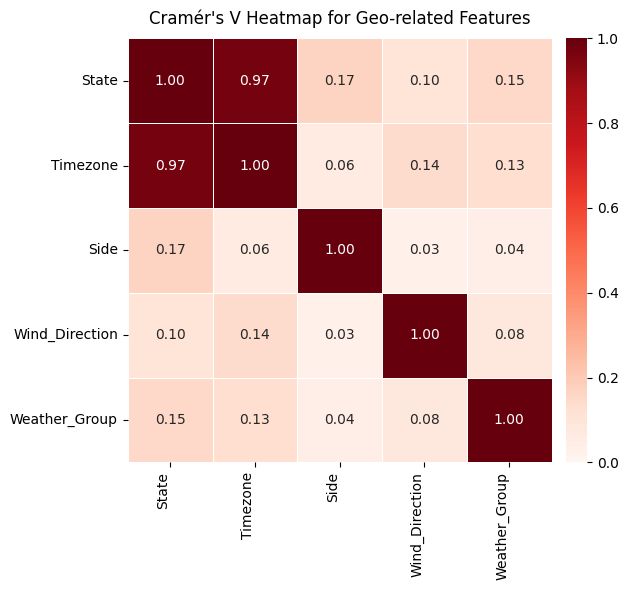

In [32]:
geo_cv_cols = [
    "State",
    "Timezone",
    "Side",
    "Wind_Direction",
    "Weather_Group"
]

geo_cv_heatmap = cramers_v_heatmap(
    df_eda[geo_cv_cols],
    geo_cv_cols,
    title = "Cramér's V Heatmap for Geo-related Features"
)

The Cramér's V heatmap shows `State` and `Timezone` are very strongly associated (0.97), far higher than any other pair in the set. All other feature pairs show weak associations (Cramér's V ≤ 0.17), including `State`–`Side` (0.17), `Timezone`–`Wind_Direction` (0.14), `State`–`Weather_Group` (0.15), and the rest below 0.10 — indicating minimal redundancy elsewhere.

[Note] Given the near-perfect correlation (0.97) and `State`'s richer information content, we drop `Timezone` rather than including both before we build prediction model.

* Road-related Features

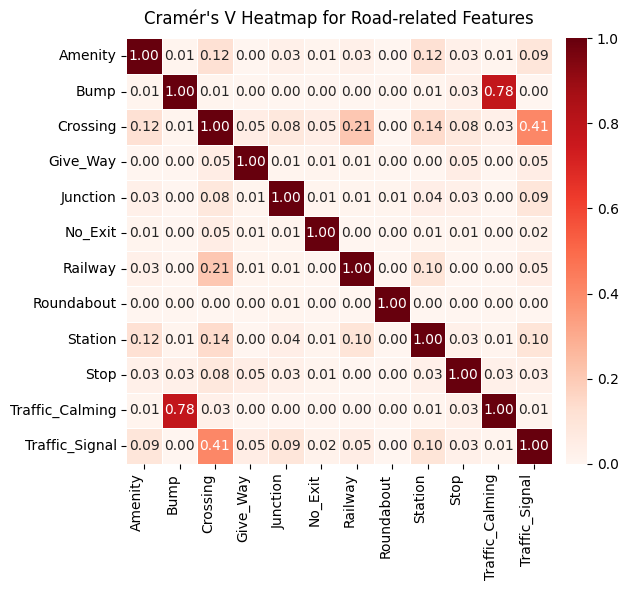

In [33]:
road_cv_heatmap = cramers_v_heatmap(
    df_eda[road_cols],
    road_cols,
    title = "Cramér's V Heatmap for Road-related Features"
)

Most pairwise correlations were weak or negligible, indicating that the majority of features provide distinct information. The strongest association was observed between `Bump` and `Traffic_Calming` (0.78), which is expected because speed bumps are a common form of traffic-calming infrastructure. `Crossing` and `Traffic_Signal` showed a moderate correlation (0.41), likely because pedestrian crossings are often installed near traffic signals. We retain all four features, as they capture different aspects of road conditions related to severity.


* Light-related Features

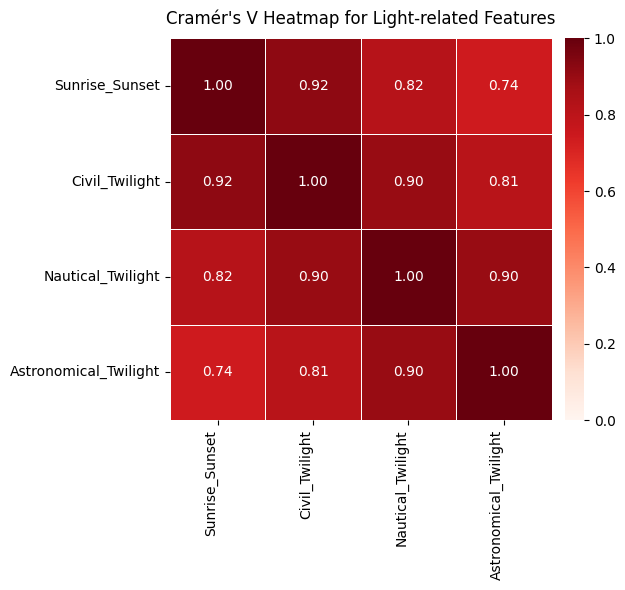

In [34]:
light_cv_heatmap = cramers_v_heatmap(
    df_eda[light_cols],
    light_cols,
    title="Cramér's V Heatmap for Light-related Features"
)

The four twilight indicators showed strong pairwise correlations (Cramér's V = 0.74–0.92), indicating substantial redundancy as they capture similar levels of darkness. We retain only `Civil_Twilight`, which has the highest average correlation with the others, making it the most representative of the group. It is also a standard and widely used threshold (sun 0–6° below the horizon) that aligns with practical contexts such as headlight use, making it both statistically sound and easy to interpret.


3-4-b. Map Plot for State

In [35]:
%pip install chart_studio

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.4/64.4 kB 3.9 MB/s eta 0:00:00


In [36]:
import numpy as np
import pandas as pd
from pyspark.sql.functions import col, lit
from statsmodels.stats.proportion import proportions_ztest


def calculate_category_lift(
    df,
    feature_col,
    target_col,
    baseline_rate=None,
    positive_value=1,
    alpha=0.05
):
    """
    Calculate category-level target rate, lift, and significance test.

    """
    if baseline_rate is None:
        baseline_rate = (
            df.selectExpr(f"avg({target_col})")
              .collect()[0][0] * 100
        )

    df_result = (
        df.select(target_col, feature_col)
          .crosstab(feature_col, target_col)
          .orderBy(feature_col + "_" + target_col)
          .withColumn(
              "count",
              col(str(0)) + col(str(1))
          )
          .withColumn(
              "prob_1",
              col(str(positive_value)) / col("count")
          )
          .withColumn(
              "baseline_rate",
              lit(baseline_rate / 100)
          )
          .withColumn(
              "lift",
              col("prob_1") - col("baseline_rate")
          )
          .withColumnRenamed(
              feature_col + "_" + target_col,
              feature_col
          )
    )

    df_result_pd = df_result.toPandas()

    df_result_pd = df_result_pd.sort_values(
        by="count"
    )

    df_result_pd["p_value"] = df_result_pd.apply(
        lambda row: proportions_ztest(
            count=row[str(positive_value)],
            nobs=row["count"],
            value=row["baseline_rate"]
        )[1],
        axis=1
    )

    df_result_pd["is_sig"] = (
        df_result_pd["p_value"] < alpha
    )

    drop_cols = [
        str(0),
        str(1),
        "count"
    ]

    df_result_pd = df_result_pd.drop(
        columns=[c for c in drop_cols if c in df_result_pd.columns]
    )

    return df_result_pd

In [37]:
df_state_pd = calculate_category_lift(
    df=df_transformed,
    feature_col="State",
    target_col="Severity",
    baseline_rate=baseline_rate
)

In [38]:
import plotly.graph_objects as go


def plot_choropleth_lift(
    df,
    location_col,
    lift_col,
    sig_col,
    rate_col="prob_1",
    baseline_col="baseline_rate",
    pvalue_col="p_value",
    baseline_rate=None,
    title="Severity Rate Lift by State",
    locationmode="USA-states",
    colorscale="RdBu_r",
    gray_color="lightgray",
    zmid=0
):
    """
    Create a choropleth map showing significant lift
    and gray non-significant areas.
    """

    df_sig = df[df[sig_col]].copy()
    df_nonsig = df[~df[sig_col]].copy()

    fig = go.Figure()

    hovertemplate = (
        "<b>%{text}</b><br>"
        f"{rate_col}: "+"%{customdata[0]:.2%}<br>"
        f"{baseline_col}: "+"%{customdata[1]:.2%}<br>"
        "Lift: %{z:.2%}<br>"
        "p-value: %{customdata[2]:.3f}"
        "<extra></extra>"
    )

    # Significant states
    fig.add_trace(
        go.Choropleth(
            locations=df_sig[location_col],
            z=df_sig[lift_col].astype(float),
            locationmode=locationmode,
            colorscale=colorscale,
            zmid=zmid,
            colorbar_title="Severity Lift (pp)",
            text=df_sig[location_col],
            customdata=df_sig[
                [rate_col, baseline_col, pvalue_col]
            ],
            hovertemplate=hovertemplate,
        )
    )

    # Non-significant states
    fig.add_trace(
        go.Choropleth(
            locations=df_nonsig[location_col],
            z=df_nonsig[lift_col].astype(float),
            locationmode=locationmode,
            colorscale=[
                [0, gray_color],
                [1, gray_color]
            ],
            showscale=False,
            text=df_nonsig[location_col],
            customdata=df_nonsig[
                [rate_col, baseline_col, pvalue_col]
            ],
            hovertemplate=hovertemplate,
        )
    )

    subtitle = ""
    if baseline_rate is not None:
        subtitle = (
            f"<br><span style='font-size:12px;color:gray'>"
            f"Baseline rate = {baseline_rate:.1%}; "
            "Gray states indicate non-significant lift (p ≥ 0.05)"
            "</span>"
        )

    fig.update_layout(
        title={
            "text": title + subtitle,
            "x": 0.5,
            "xanchor": "center",
        },
        geo_scope="usa",
    )

    return fig

In [39]:
plot_choropleth_lift(
    df=df_state_pd,
    location_col="State",
    lift_col="lift",
    sig_col="is_sig",
    baseline_rate=baseline_rate/100
)

State-level analysis revealed substantial variation in severe accident rates across regions, with states such as Wisconsin, Colorado, Illinois, and Massachusetts showing relatively higher severity rates. These differences may reflect variations in road environments, traffic patterns, weather conditions, and emergency response accessibility. However, the results represent associations rather than causal effects, and additional analysis is needed to identify the underlying drivers of accident severity.


3-4-c. Rate Lift Plots

In [40]:
def plot_binary_feature_impact(
    df,
    feature_list,
    target_col,
    baseline_rate=baseline_rate,
    category_order=None,
    positive_value="True",
    alpha_sig=0.05,
    title=None,
    figsize=(3, 3),
    height_ratios=[2,1],
    dpi=200,
    x_rotation=0,
    count_log=False,
    legend_loc="upper right"
):
    """
    Compare outcome rates for binary features against baseline
    and visualize rate differences and sample sizes.
    """

    results = []

    for feature in feature_list:
        flag = df[feature] == positive_value
        sub = df.loc[flag]

        n = len(sub)

        if n == 0:
            continue

        rate = sub[target_col].mean() * 100
        diff = rate - baseline_rate

        ct = pd.crosstab(flag, df[target_col])

        p_value = (
            chi2_contingency(ct)[1]
            if ct.shape[0] == 2
            else np.nan
        )

        results.append({
            "feature": feature,
            "diff": diff,
            "n_flagged": n,
            "p_value": p_value
        })

    res_df = pd.DataFrame(results)

    if category_order is not None:
        res_df["feature"] = pd.Categorical(
            res_df["feature"],
            categories=category_order,
            ordered=True
        )
        res_df = res_df.sort_values("feature")
    else:
        res_df = res_df.sort_values(
            "diff",
            ascending=False
        )

    x = res_df["feature"].astype(str)

    fig, axes = plt.subplots(
        2,
        1,
        figsize=figsize,
        dpi=dpi,
        sharex=True,
        gridspec_kw={
            "height_ratios": height_ratios,
            "hspace": 0.15
        }
    )

    # ---------------- Panel 1 ---------------- #

    ax1 = axes[0]

    colors = np.where(
        res_df["diff"] > 0,
        "#d62728",
        "#1f77b4"
    )

    bars = ax1.bar(x, res_df["diff"], color=colors)

    is_sig = res_df["p_value"] < alpha_sig

    for bar, sig in zip(bars, is_sig):
        bar.set_alpha(0.85 if sig else 0.35)

    label = (
        f"Δ {target_col} Rate Lift(pp)"
    )

    ax1.set_ylabel(label, fontsize=5)
    ax1.axhline(0, color="black", linewidth=0.8)
    ax1.set_title(
        title if title else f"Change in {target_col} Rate by Feature",
        fontsize=6,
        pad=10
    )
    ax1.text(
        0.5, 1.01,
        f"Baseline rate = {baseline_rate:.1f}%",
        transform=ax1.transAxes,
        ha="center",
        va="bottom",
        fontsize=5,
        color="gray"
    )
    ax1.tick_params(axis="both", labelsize=5)
    ax1.legend(
        handles=[
            mpatches.Patch(
                color="gray",
                alpha=0.85,
                label=f"p < {alpha_sig}"
            ),
            mpatches.Patch(
                color="gray",
                alpha=0.35,
                label=f"p ≥ {alpha_sig}"
            )
        ],
        fontsize=5,
        loc=legend_loc,
        frameon=False
    )

    # ---------------- Panel 2 ---------------- #

    ax2 = axes[1]
    ax2.bar(
        x,
        res_df["n_flagged"],
        color="#4C72B0",
        alpha=0.8
    )
    ax2.set_ylabel("Count", fontsize=5)
    ax2.tick_params(
        axis="x",
        labelsize=5,
        rotation=x_rotation
    )
    ax2.tick_params(
        axis="y",
        labelsize=5
    )
    if count_log:
      ax2.set_yscale("log")

    plt.show()

    return res_df

* Day of Week

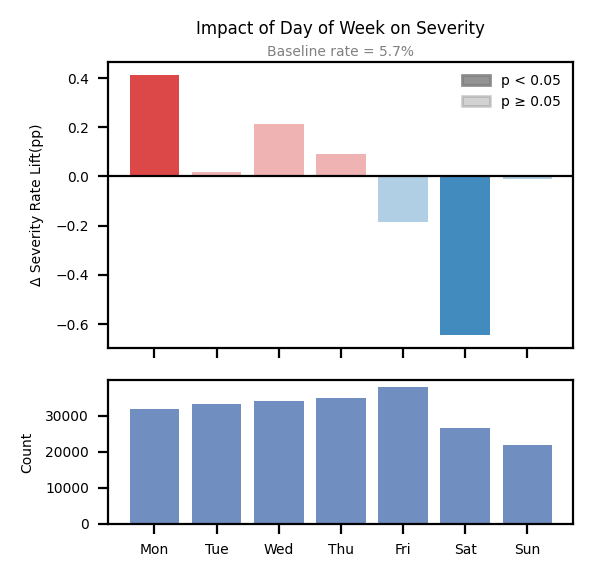

In [41]:
dow_order = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']

dow_dummies = pd.get_dummies(
    df_eda["Day_of_Week"]
)

df_dow = pd.concat(
    [df_eda, dow_dummies],
    axis=1
)

dow_result = plot_binary_feature_impact(
    df=df_dow,
    feature_list=dow_dummies.columns.tolist(),
    target_col="Severity",
    category_order=dow_order,
    positive_value=True,
    title="Impact of Day of Week on Severity"
)

Accident severity is slightly higher on weekdays, with Monday showing the clearest increase, while weekends—especially Saturday—show lower severity rates. This may be driven by heavier weekday traffic and commuting patterns, which increase exposure to congestion-related crashes and more complex driving conditions.

* Hour

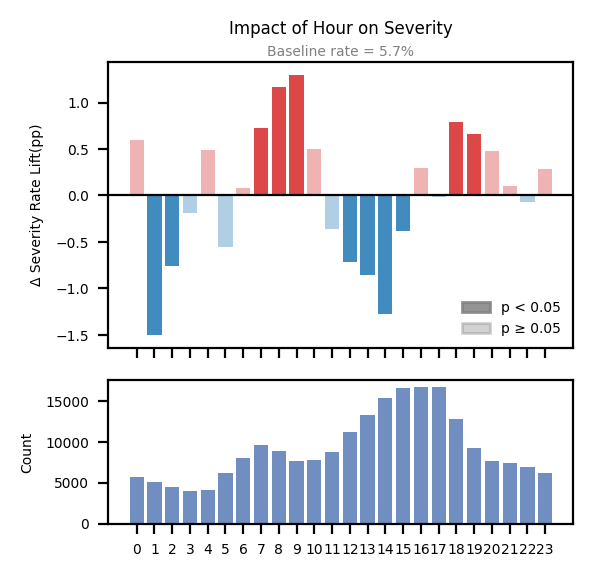

In [42]:
hour_order = [str(h) for h in range(24)]

hour_dummies = pd.get_dummies(
    df_eda["Hour"]
)

df_hour = pd.concat(
    [df_eda, hour_dummies],
    axis=1
)

hour_result = plot_binary_feature_impact(
    df=df_hour,
    feature_list=hour_dummies.columns.tolist(),
    target_col="Severity",
    category_order=hour_order,
    positive_value=True,
    title="Impact of Hour on Severity",
    legend_loc="lower right"
)

Accident severity follows a clear time-of-day pattern, with higher severity during morning and evening commute hours and lower severity overnight and midday. This pattern likely reflects increased commuting traffic, congestion, and time pressure during peak hours, which can contribute to more severe crashes.

* Side

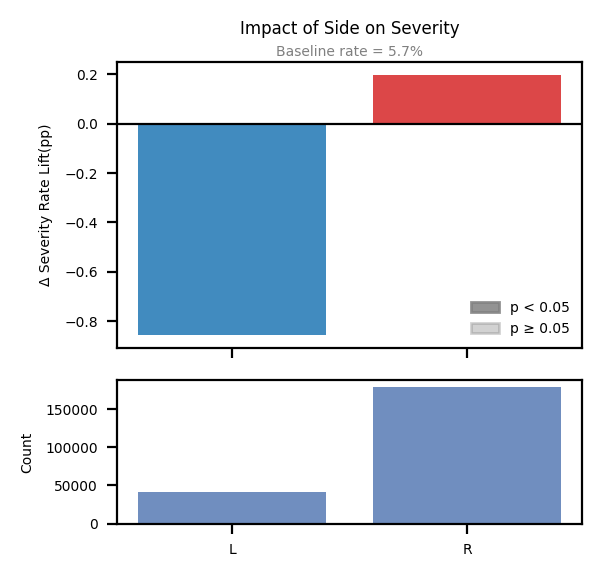

In [43]:
side_order = ["L", "R"]

side_dummies = pd.get_dummies(
    df_eda["Side"]
)

df_side = pd.concat(
    [df_eda, side_dummies],
    axis=1
)

side_result = plot_binary_feature_impact(
    df=df_side,
    feature_list=side_dummies.columns.tolist(),
    target_col="Severity",
    category_order=side_order,
    positive_value=True,
    title="Impact of Side on Severity",
    legend_loc="lower right"
)

Accident severity differs by road side, with L-side accidents showing lower severity and R-side accidents showing slightly higher severity. Since Side reflects the recorded location of the accident rather than crash mechanics, this pattern likely captures geographic or data-collection differences rather than a direct causal effect.

* Time Zone

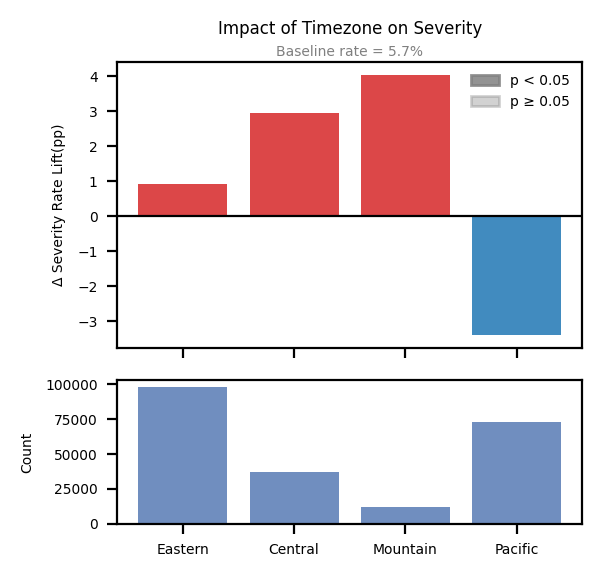

In [44]:
tz_order = ["Eastern", "Central", "Mountain", "Pacific"]

tz_dummies = pd.get_dummies(
    df_eda["Timezone"]
)

tz_dummies.columns = (
    tz_dummies.columns
    .str.replace("^US/", "", regex=True)
)

df_tz = pd.concat(
    [df_eda, tz_dummies],
    axis=1
)

tz_result = plot_binary_feature_impact(
    df=df_tz,
    feature_list=tz_dummies.columns.tolist(),
    target_col="Severity",
    category_order=tz_order,
    positive_value=True,
    title="Impact of Timezone on Severity"
)

Accident severity varies across timezones, with higher severity observed in Eastern, Central, and especially Mountain regions, while Pacific shows lower severity. However, because `Timezone` largely overlaps with `State`, these differences likely reflect regional factors such as road environments, geography, and infrastructure rather than a direct timezone effect.


* Wind Direction

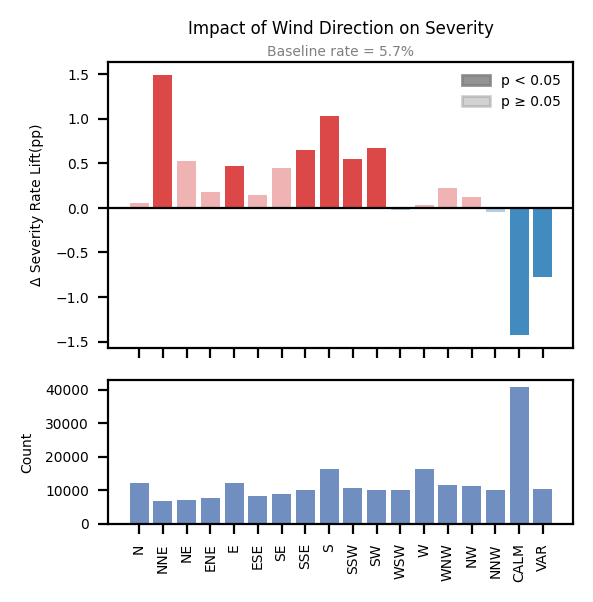

In [45]:
wind_order = [
    "N", "NNE", "NE", "ENE",
    "E", "ESE", "SE", "SSE",
    "S", "SSW", "SW", "WSW",
    "W", "WNW", "NW", "NNW",
    "CALM", "VAR"
]

wind_dummies = pd.get_dummies(
    df_eda["Wind_Direction"]
)

df_wind = pd.concat(
    [df_eda, wind_dummies],
    axis=1
)

wind_result = plot_binary_feature_impact(
    df=df_wind,
    feature_list=wind_dummies.columns.tolist(),
    target_col="Severity",
    category_order=wind_order,
    positive_value=True,
    title="Impact of Wind Direction on Severity",
    x_rotation=90
)

Accident severity shows some variation by wind direction, with several southerly and easterly directions associated with higher severity, while calm conditions show lower severity. Since wind direction is weakly related to other geographic features, it is retained for prediction, though these patterns likely reflect regional or seasonal weather differences rather than a direct causal effect of wind direction.

* Weather Group (From Description)

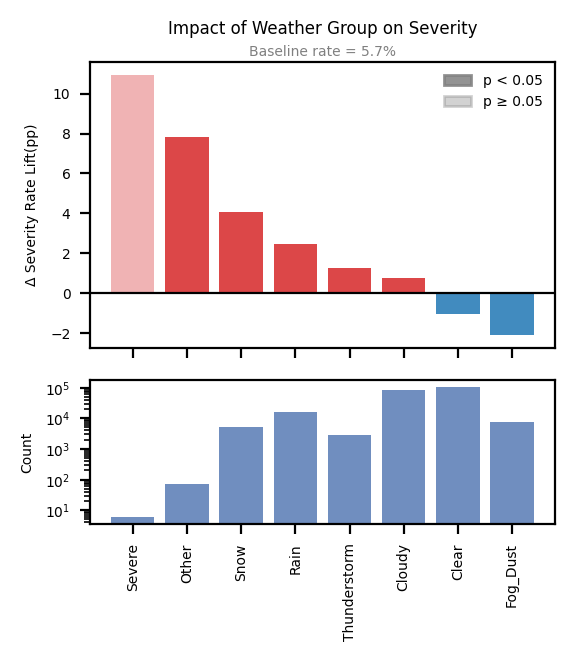

In [46]:
weather_dummies = pd.get_dummies(
    df_eda["Weather_Group"]
)

df_weather = pd.concat(
    [df_eda, weather_dummies],
    axis=1
)

weather_result = plot_binary_feature_impact(
    df=df_weather,
    feature_list=weather_dummies.columns.tolist(),
    target_col="Severity",
    positive_value=True,
    title="Impact of Weather Group on Severity",
    x_rotation=90,
    count_log=True
)

Accident severity is higher under adverse weather conditions such as snow, rain, thunderstorms, and fog/dust, while clear and cloudy conditions show lower severity rates. This pattern likely reflects reduced visibility and road traction during hazardous weather, although rare weather categories should be interpreted cautiously due to limited observations.

* Road-related Features

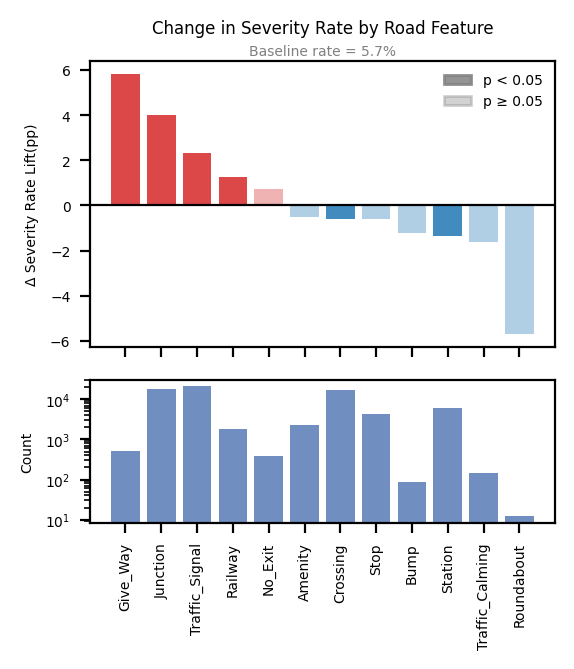

In [47]:
road_feature_results = plot_binary_feature_impact(
    df_eda,
    feature_list=road_cols,
    target_col="Severity",
    positive_value="True",
    title="Change in Severity Rate by Road Feature",
    x_rotation=90,
    count_log=True
)

Road-related features show that locations with higher traffic conflict points, such as `Give_Way`, `Junction`, `Traffic_Signal`, and `Railway`, are associated with higher accident severity, while controlled environments like `Stop`, `Crossing`, and `Station` show lower severity. This pattern likely reflects the role of traffic flow complexity and vehicle interaction, where more conflict points and higher speeds increase crash severity risk.


* Light-related Features

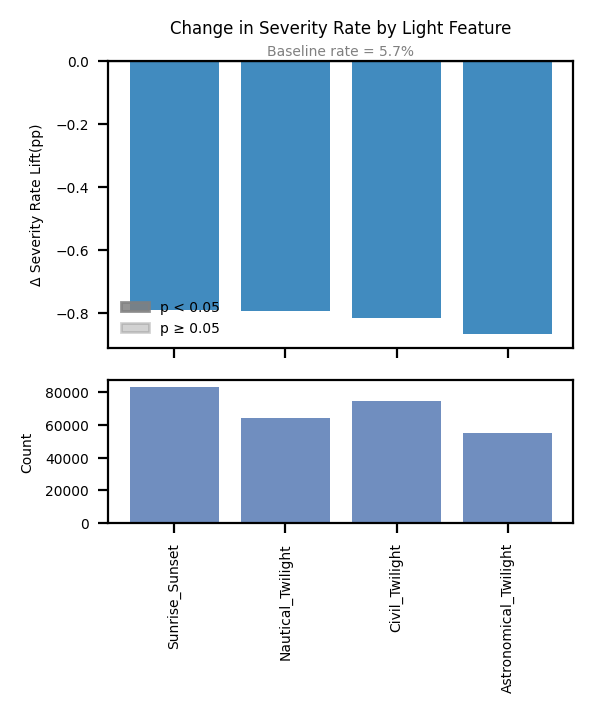

In [48]:
light_feature_results = plot_binary_feature_impact(
    df_eda,
    feature_list=light_cols,
    target_col="Severity",
    positive_value="Night",
    title="Change in Severity Rate by Light Feature",
    height_ratios=[2,1],
    x_rotation=90,
    legend_loc="lower left"
)

Twilight indicators show that low-light transition periods are associated with slightly lower accident severity, possibly because drivers become more cautious during these conditions. Since the four indicators capture similar information, we retain only `Civil_Twilight` as the most representative and interpretable measure of twilight conditions, reducing redundancy while preserving predictive information.


In [49]:
weather_cols = [col for col in weather_cols if col not in {"Temperature(F)"}]

other_cat_cols = [col for col in other_cat_cols if col not in {"Timezone"}]

road_cols = [
    col for col in road_cols
    if col not in {
        "Turning_Loop",
        "Roundabout"
        }
]

light_cols = [
    col for col in light_cols
    if col not in {
        "Sunrise_Sunset",
        "Nautical_Twilight",
        "Astronomical_Twilight"
        }
]

In [50]:
numeric_cols = weather_cols
categorical_cols = other_cat_cols + road_cols + light_cols
feature_cols = numeric_cols + categorical_cols

**4. Model Prediction**

*4-1. Synthetic Minority Oversampling Technique (SMOTE)*

For the binary classification task (Severity = 0 or 1), I used multiple models for the task such as logistic regression, SVM, random forest, and gradient boosting and compared their performance. Before running the models, I conducted Synthesized Minority Oversampling Technique (SMOTE) to deal with the issue of imbalance in our dataset.

In [51]:
df_imbalanced = df_sampled.select(feature_cols + [target_col])

In [52]:
df_train_imbalanced, df_test = df_imbalanced.randomSplit([0.7, 0.3], seed=42)
df_train_imbalanced_pd = df_train_imbalanced.toPandas()

# convert the type of categorical features from object to category
df_train_imbalanced_pd = df_train_imbalanced_pd.astype(
    {col: 'category' for col in categorical_cols}
)

X_train_imbalanced = df_train_imbalanced_pd.drop([target_col], axis=1)
y_train_imbalanced = df_train_imbalanced_pd[target_col]

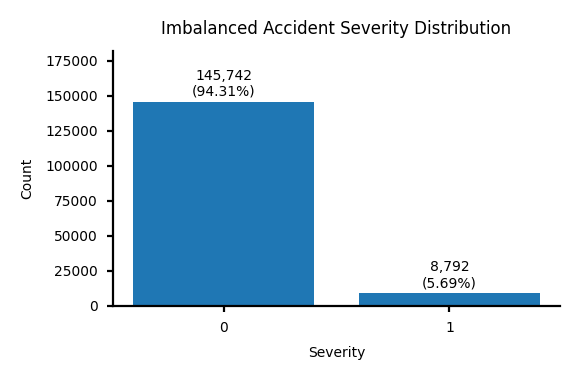

In [53]:
train_imbalanced_target_dist = plot_distribution_percentage(
    df_train_imbalanced,
    group_col=target_col,
    title="Imbalanced Accident Severity Distribution",
    xlabel=target_col
)

In [54]:
pip install imbalanced-learn

In [55]:
from imblearn.over_sampling import SMOTENC

smote_nc = SMOTENC(
    categorical_features = categorical_cols,
    random_state = 42
)

X_resampled, y_resampled = smote_nc.fit_resample(
    X_train_imbalanced,
    y_train_imbalanced
)

df_resampled_pd = pd.concat([y_resampled, X_resampled], axis = 1)
df_train_balanced = spark.createDataFrame(df_resampled_pd)

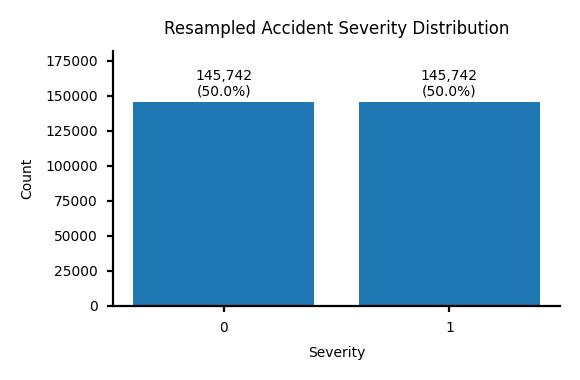

In [56]:
train_balanced_target_dist = plot_distribution_percentage(
    df_train_balanced,
    group_col=target_col,
    title="Resampled Accident Severity Distribution",
    xlabel=target_col
)

*4-2. Pipelie and Evaluator for Models*

In [57]:
from pyspark.ml.evaluation import BinaryClassificationEvaluator
from pyspark.ml.feature import VectorAssembler, StandardScaler, StringIndexer, OneHotEncoder
from pyspark.ml.tuning import CrossValidator, ParamGridBuilder
from pyspark.ml import Pipeline

In [58]:
# Assemble numeric features
assembler_numeric = VectorAssembler(
    inputCols=numeric_cols,
    outputCol="numeric_vec"
)

# Standardize numeric features
scaler = StandardScaler(
    inputCol="numeric_vec",
    outputCol="numeric_scaled",
    withStd=True,
    withMean=True
)

# Keep the scaled vector under a consistent name
assembler_scaled_numeric = VectorAssembler(
    inputCols=["numeric_scaled"],
    outputCol="numeric_features"
)

# Index categorical features
indexers = [
    StringIndexer(
        inputCol=col,
        outputCol=f"{col}_index"
    )
    for col in categorical_cols
]

# One-hot encode categorical features
encoders = [
    OneHotEncoder(
        inputCol=f"{col}_index",
        outputCol=f"{col}_ohe"
    )
    for col in categorical_cols
]

# Assemble one-hot encoded categorical features
assembler_categorical = VectorAssembler(
    inputCols=[f"{col}_ohe" for col in categorical_cols],
    outputCol="categorical_features"
)

# Assemble all features
assembler_all = VectorAssembler(
    inputCols=["numeric_features", "categorical_features"],
    outputCol="features"
)

In [59]:
# create an evaluator to get AUC of binaryclassification models
evaluator_auc = BinaryClassificationEvaluator(
    labelCol=target_col,
    metricName="areaUnderROC"
)

*4-3. Model Fitting*

In [60]:
from pyspark.ml import Pipeline
from pyspark.ml.tuning import ParamGridBuilder, CrossValidator

def train_classifier_cv(
    model,
    param_grid,
    train_df,
    evaluator,
    indexers,
    encoders,
    assembler_numeric,
    scaler,
    assembler_scaled_numeric,
    assembler_categorical,
    assembler_all,
    num_folds=5,
    parallelism=4
):
    """
    Train and tune a Spark ML classification model using cross-validation.

    Parameters
    ----------
    model : Spark ML classifier
        Classification model
        (e.g., LogisticRegression, RandomForestClassifier, GBTClassifier)

    param_grid : list
        Hyperparameter grid generated by ParamGridBuilder

    train_df : Spark DataFrame
        Training dataset

    evaluator : Spark evaluator
        Model evaluation metric (e.g., BinaryClassificationEvaluator)

    Returns
    -------
    cv_model : CrossValidatorModel
        Fitted cross-validation model
    """

    # Create preprocessing + modeling pipeline
    pipeline = Pipeline(
        stages=(
            indexers
            + encoders
            + [assembler_numeric, scaler]
            + [assembler_scaled_numeric, assembler_categorical]
            + [assembler_all, model]
        )
    )

    # Cross-validation
    crossval = CrossValidator(
        estimator=pipeline,
        estimatorParamMaps=param_grid,
        evaluator=evaluator,
        numFolds=num_folds,
        parallelism=parallelism
    )

    # Fit model
    cv_model = crossval.fit(train_df)

    return cv_model

* Logistic regression

In [61]:
from pyspark.ml.classification import LogisticRegression
from pyspark.ml.tuning import ParamGridBuilder


lr = LogisticRegression(
    featuresCol="features",
    labelCol=target_col,
    maxIter=100
)

lr_paramGrid = (
    ParamGridBuilder()
    .addGrid(lr.regParam, [0.01, 0.1, 1.0])
    .addGrid(lr.elasticNetParam, [0.0, 0.5, 1.0])
    .build()
)

lr_model = train_classifier_cv(
    model=lr,
    param_grid=lr_paramGrid,
    train_df=df_train_balanced,
    evaluator=evaluator_auc,
    indexers=indexers,
    encoders=encoders,
    assembler_numeric=assembler_numeric,
    scaler=scaler,
    assembler_scaled_numeric=assembler_scaled_numeric,
    assembler_categorical=assembler_categorical,
    assembler_all=assembler_all
)

In [62]:
lr_bestModel = lr_model.bestModel.stages[-1]
print("Best Model Hyperparameters:")
print(" - regParam:", lr_bestModel.getRegParam())
print(" - elasticNetParam:", lr_bestModel.getElasticNetParam())

Best Model Hyperparameters:
 - regParam: 0.01
 - elasticNetParam: 0.0


* Random Forest

In [63]:
from pyspark.ml.classification import RandomForestClassifier

rf = RandomForestClassifier(
    featuresCol="features",
    labelCol=target_col,
    seed=42
)

rf_paramGrid = (
    ParamGridBuilder()
    .addGrid(rf.numTrees, [50, 100])
    .addGrid(rf.maxDepth, [5, 10])
    .addGrid(rf.maxBins, [32, 64])
    .build()
)

rf_model = train_classifier_cv(
    model=rf,
    param_grid=rf_paramGrid,
    train_df=df_train_balanced,
    evaluator=evaluator_auc,
    indexers=indexers,
    encoders=encoders,
    assembler_numeric=assembler_numeric,
    scaler=scaler,
    assembler_scaled_numeric=assembler_scaled_numeric,
    assembler_categorical=assembler_categorical,
    assembler_all=assembler_all
)

In [64]:
rf_bestModel = rf_model.bestModel.stages[-1]
print("Best Model Hyperparameters:")
print("Best numTrees:", rf_bestModel.getNumTrees)
print("Best maxDepth:", rf_bestModel.getMaxDepth())
print("Best maxBins:", rf_bestModel.getMaxBins())

Best Model Hyperparameters:
Best numTrees: 100
Best maxDepth: 10
Best maxBins: 64


* Gradient Boosting Trees

In [65]:
from pyspark.ml.classification import GBTClassifier

gbt = GBTClassifier(
    featuresCol="features",
    labelCol=target_col,
    seed=42
)

gbt_paramGrid = (
    ParamGridBuilder()
    .addGrid(gbt.maxIter, [50, 100])
    .addGrid(gbt.maxDepth, [3, 5])
    .addGrid(gbt.stepSize, [0.05, 0.1])
    .build()
)

gbt_model = train_classifier_cv(
    model=gbt,
    param_grid=gbt_paramGrid,
    train_df=df_train_balanced,
    evaluator=evaluator_auc,
    indexers=indexers,
    encoders=encoders,
    assembler_numeric=assembler_numeric,
    scaler=scaler,
    assembler_scaled_numeric=assembler_scaled_numeric,
    assembler_categorical=assembler_categorical,
    assembler_all=assembler_all
)

In [66]:
gbt_bestModel = gbt_model.bestModel.stages[-1]
print("Best Model Hyperparameters:")
print("Best maxIter:", gbt_bestModel.getMaxIter())
print("Best maxDepth:", gbt_bestModel.getMaxDepth())
print("Best stepSize:", gbt_bestModel.getStepSize())

Best Model Hyperparameters:
Best maxIter: 100
Best maxDepth: 5
Best stepSize: 0.1


* Multilayer Perception (Artificial Neural Network)

In [67]:
preprocess_pipeline = Pipeline(
    stages=(
        indexers
        + encoders
        + [
            assembler_numeric,
            scaler,
            assembler_scaled_numeric,
            assembler_categorical,
            assembler_all
        ]
    )
)

preprocess_model = preprocess_pipeline.fit(df_train_balanced)

df_train_preprocessed = preprocess_model.transform(df_train_balanced)

n_features = len(
    df_train_preprocessed
    .select("features")
    .first()["features"]
)

print(n_features)

119


In [68]:
from pyspark.ml.classification import MultilayerPerceptronClassifier
from pyspark.ml.tuning import ParamGridBuilder

# Network architecture
layers = [n_features, 32, 8, 2]

# Initialize MLP classifier
mlp = MultilayerPerceptronClassifier(
    layers=layers,
    featuresCol="features",
    labelCol=target_col,
    seed=42
)

# Hyperparameter grid
mlp_paramGrid = (
    ParamGridBuilder()
    .addGrid(mlp.maxIter, [50, 100])
    .addGrid(mlp.stepSize, [0.01, 0.05])
    .build()
)

# Train model
mlp_model = train_classifier_cv(
    model=mlp,
    param_grid=mlp_paramGrid,
    train_df=df_train_balanced,
    evaluator=evaluator_auc,
    indexers=indexers,
    encoders=encoders,
    assembler_numeric=assembler_numeric,
    scaler=scaler,
    assembler_scaled_numeric=assembler_scaled_numeric,
    assembler_categorical=assembler_categorical,
    assembler_all=assembler_all
)

In [69]:
mlp_bestModel = mlp_model.bestModel.stages[-1]

print("Best Model Hyperparameters:")
print(f" - maxIter: {mlp_bestModel.getMaxIter()}")
print(f" - stepSize: {mlp_bestModel.getStepSize()}")

Best Model Hyperparameters:
 - maxIter: 100
 - stepSize: 0.01


* XGBoost

In [70]:
%pip install synapseml

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 621.1/621.1 kB 25.7 MB/s eta 0:00:00


In [71]:
from xgboost.spark import SparkXGBClassifier

xgb = SparkXGBClassifier(
    features_col="features",
    label_col=target_col,
    prediction_col="prediction",
    probability_col="probability",
    eval_metric="auc",
    num_workers=4,
    random_state=42
)


xgb_paramGrid = (
    ParamGridBuilder()
    .addGrid(xgb.max_depth, [3, 5])
    .addGrid(xgb.n_estimators, [100, 200])
    .addGrid(xgb.learning_rate, [0.05, 0.1])
    .addGrid(xgb.subsample, [0.8, 1.0])
    .addGrid(xgb.colsample_bytree, [0.8, 1.0])
    .build()
)


xgb_model = train_classifier_cv(
    model=xgb,
    param_grid=xgb_paramGrid,
    train_df=df_train_balanced,
    evaluator=evaluator_auc,
    indexers=indexers,
    encoders=encoders,
    assembler_numeric=assembler_numeric,
    scaler=scaler,
    assembler_scaled_numeric=assembler_scaled_numeric,
    assembler_categorical=assembler_categorical,
    assembler_all=assembler_all
)

INFO:XGBoost-PySpark:Running xgboost-3.3.0 on 4 workers with
	booster params: {'colsample_bytree': 1.0, 'device': 'cpu', 'eval_metric': 'auc', 'learning_rate': 0.05, 'max_depth': 3, 'objective': 'binary:logistic', 'random_state': 42, 'subsample': 1.0, 'nthread': 1}
	train_call_kwargs_params: {'verbose_eval': True, 'num_boost_round': 100}
	dmatrix_kwargs: {'nthread': 1, 'missing': nan}
INFO:XGBoost-PySpark:Running xgboost-3.3.0 on 4 workers with
	booster params: {'colsample_bytree': 0.8, 'device': 'cpu', 'eval_metric': 'auc', 'learning_rate': 0.05, 'max_depth': 3, 'objective': 'binary:logistic', 'random_state': 42, 'subsample': 1.0, 'nthread': 1}
	train_call_kwargs_params: {'verbose_eval': True, 'num_boost_round': 100}
	dmatrix_kwargs: {'nthread': 1, 'missing': nan}
INFO:XGBoost-PySpark:Running xgboost-3.3.0 on 4 workers with
	booster params: {'colsample_bytree': 0.8, 'device': 'cpu', 'eval_metric': 'auc', 'learning_rate': 0.05, 'max_depth': 3, 'objective': 'binary:logistic', 'random_st

In [72]:
xgb_bestModel = xgb_model.bestModel.stages[-1]

print("Best Model Hyperparameters:")
print(
    f" - max_depth: "
    f"{xgb_bestModel.getOrDefault(xgb_bestModel.max_depth)}"
)
print(
    f" - n_estimators: "
    f"{xgb_bestModel.getOrDefault(xgb_bestModel.n_estimators)}"
)
print(
    f" - learning_rate: "
    f"{xgb_bestModel.getOrDefault(xgb_bestModel.learning_rate)}"
)
print(
    f" - subsample: "
    f"{xgb_bestModel.getOrDefault(xgb_bestModel.subsample)}"
)
print(
    f" - colsample_bytree: "
    f"{xgb_bestModel.getOrDefault(xgb_bestModel.colsample_bytree)}"
)

Best Model Hyperparameters:
 - max_depth: 5
 - n_estimators: 200
 - learning_rate: 0.1
 - subsample: 0.8
 - colsample_bytree: 0.8


**5. Model Evaluation**

In [73]:
from pyspark.ml.evaluation import MulticlassClassificationEvaluator

metrics = {
    "Accuracy": "accuracy",
    "Precision": "weightedPrecision",
    "Recall": "weightedRecall",
    "F1 Score": "f1"
}

evaluators = {
    name: MulticlassClassificationEvaluator(
        labelCol=target_col,
        predictionCol="prediction",
        metricName=metric
    )
    for name, metric in metrics.items()
}

evaluation_results = []

models = {
    "lr": lr_model,
    "rf": rf_model,
    "gbt": gbt_model,
    "mlp": mlp_model,
    "xgb": xgb_model
}

for name, model in models.items():

    predictions = model.transform(df_test)

    results = {
        "Model": name,
        "AUC": evaluator_auc.evaluate(predictions)
    }

    for metric_name, evaluator in evaluators.items():
        results[metric_name] = evaluator.evaluate(predictions)

    evaluation_results.append(results)

In [74]:
from pyspark.sql import functions as F

evaluation_df = (
    spark.createDataFrame(evaluation_results)
         .select("Model", "Recall", "F1 Score", "AUC", "Precision", "Accuracy")
)

metric_cols = ["Recall", "F1 Score", "AUC", "Precision", "Accuracy"]

for c in metric_cols:
    evaluation_df = evaluation_df.withColumn(c, F.round(F.col(c), 4))

evaluation_df.show()

+-----+------+--------+------+---------+--------+
|Model|Recall|F1 Score|   AUC|Precision|Accuracy|
+-----+------+--------+------+---------+--------+
|   lr|0.7259|  0.7982|0.7314|   0.9215|  0.7259|
|   rf|0.7262|  0.7984|0.7469|   0.9214|  0.7262|
|  gbt|0.8606|  0.8836| 0.734|   0.9134|  0.8606|
|  mlp| 0.737|  0.8058|0.7364|   0.9198|   0.737|
|  xgb|0.9098|  0.9117|0.7361|   0.9138|  0.9098|
+-----+------+--------+------+---------+--------+



Since the primary objective is to minimize missed severe accidents by identify severe accidents correctly, recall is considered the most important evaluation metric because it measures the proportion of severe accidents correctly identified. F1-score is also important as it balances recall and precision, while ROC-AUC provides a threshold-independent measure of the model's overall discriminative ability. Precision and accuracy are less suitable as the primary evaluation metrics because they do not directly measure the model's ability to identify severe accidents.

Among the evaluated models, XGBoost achieved the highest recall (0.9098) and F1-score (0.9117), indicating that it identified the largest proportion of severe accidents while maintaining high precision (0.9138). Gradient Boosted Trees ranked second, with a recall of 0.8606 and an F1-score of 0.8836. In contrast, Logistic Regression, Random Forest, and the Multilayer Perceptron achieved similar recall values of approximately 0.73, indicating that they detected fewer severe accidents. Although Random Forest achieved the highest ROC-AUC (0.7469), its recall was substantially lower than that of XGBoost. Therefore, given the objective of minimizing missed severe accidents, XGBoost provides the most suitable overall performance among the evaluated models.


**6. Model Interpretation**

* XGBoost - Feature Importances

In [75]:
from pyspark.sql.functions import col, count, concat, lit

categorical_index = []

for c in categorical_cols:
    categories = (
        df_train_preprocessed
        .select(f"{c}_index", c)
        .distinct()
        .orderBy(f"{c}_index")
        .withColumn(
            f"index_{c}",
            concat(lit(f"{c}_"), col(c))
        )
        .select(f"index_{c}")
        .rdd.flatMap(lambda x: x)
        .collect()
    )

    categorical_index.extend(categories[:-1])

feature_list = numeric_cols + categorical_index

In [76]:
xgb_importance = xgb_bestModel.get_feature_importances(importance_type="gain")
xgb_importance_df = pd.DataFrame({
    "feature": feature_list,
    "gain": 0.0
})

for key, value in xgb_importance.items():
    idx = int(key[1:])
    xgb_importance_df.loc[idx, "gain"] = value

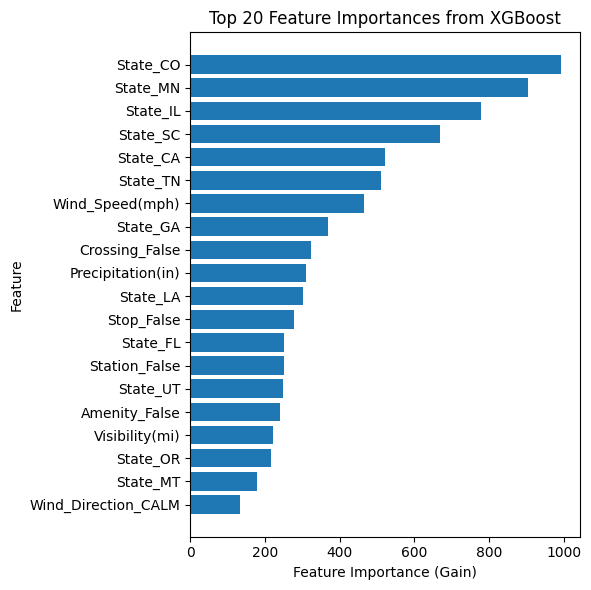

In [77]:
top_n = 20

xgb_top_importance = (
    xgb_importance_df
    .sort_values("gain", ascending=False)
    .head(top_n)
)

plt.figure(figsize=(6, 6))
plt.barh(
    xgb_top_importance["feature"],
    xgb_top_importance["gain"]
)
plt.gca().invert_yaxis()  # Highest importance at the top

plt.xlabel("Feature Importance (Gain)")
plt.ylabel("Feature")
plt.title("Top 20 Feature Importances from XGBoost")

plt.tight_layout()
plt.show()

The most striking finding is that state-related variables dominate the feature importance rankings. Specifically, `State_CO` (Colorado), `State_MN` (Minnesota), `State_IL` (Illinois), and `State_SC` (South Carolina) are the four most influential features, followed by several other state indicators such as California, Tennessee, Georgia, Louisiana, Florida, Utah, Oregon, and Montana. This suggests that geographical location plays a critical role in predicting accident severity, likely because states differ in factors such as road infrastructure, traffic conditions, weather patterns, speed limits, and reporting practices.

Among the continuous variables, `Wind_Speed(mph)` is the most important environmental factor, indicating that stronger winds are associated with differences in accident severity. `Precipitation(in)` and `Visibility(mi)` also appear among the top features, highlighting that adverse weather conditions contribute substantially to the model's predictions.

Several binary road-environment features, including `Crossing_False`, `Stop_False`, `Station_False`, and `Amenity_False`, are also identified as important. These variables indicate whether an accident occurred away from specific roadway features or nearby facilities, suggesting that the surrounding road environment provides useful information for distinguishing severe from non-severe accidents.

Finally, `Wind_Direction_CALM` has the lowest importance among the top 20 features, implying that while wind direction contributes to the model, its impact is relatively small compared with geographic location and weather-related variables.

**7. Model Inference**

In [78]:
df_test_preprocessed = preprocess_model.transform(df_test)

xgb_predictions = xgb_bestModel.transform(df_test_preprocessed)

xgb_predictions.select(
    "Severity",
    "prediction",
    "probability",
).show(10, truncate=False)

+--------+----------+-----------------------------------------+
|Severity|prediction|probability                              |
+--------+----------+-----------------------------------------+
|0       |0.0       |[0.8768517374992371,0.12314824014902115] |
|0       |1.0       |[0.30441009998321533,0.6955899000167847] |
|0       |0.0       |[0.9548903107643127,0.04510966315865517] |
|0       |1.0       |[0.015408515930175781,0.9845914840698242]|
|1       |1.0       |[0.055728137493133545,0.9442718625068665]|
|0       |0.0       |[0.9564486145973206,0.043551381677389145]|
|0       |0.0       |[0.9054444432258606,0.09455556422472]    |
|0       |0.0       |[0.9573007225990295,0.04269927740097046] |
|1       |0.0       |[0.6199442744255066,0.3800557255744934]  |
|0       |0.0       |[0.9252135157585144,0.07478649169206619] |
+--------+----------+-----------------------------------------+
only showing top 10 rows


In [79]:
from pyspark.sql.functions import udf
from pyspark.sql.types import DoubleType

extract_prob = udf(lambda v: float(v[1]), DoubleType())

xgb_inference_df = (
    xgb_predictions
    .withColumn("predicted_probability", extract_prob("probability"))
    .select(
        "Severity",
        "prediction",
        "predicted_probability"
    )
)

xgb_inference_df.show(10, truncate=False)

+--------+----------+---------------------+
|Severity|prediction|predicted_probability|
+--------+----------+---------------------+
|0       |0.0       |0.12314824014902115  |
|0       |1.0       |0.6955899000167847   |
|0       |0.0       |0.04510966315865517  |
|0       |1.0       |0.9845914840698242   |
|1       |1.0       |0.9442718625068665   |
|0       |0.0       |0.043551381677389145 |
|0       |0.0       |0.09455556422472     |
|0       |0.0       |0.04269927740097046  |
|1       |0.0       |0.3800557255744934   |
|0       |0.0       |0.07478649169206619  |
+--------+----------+---------------------+
only showing top 10 rows


In [80]:
xgb_inference_df.groupBy("prediction").count().show()

+----------+-----+
|prediction|count|
+----------+-----+
|       0.0|61564|
|       1.0| 4158|
+----------+-----+



In [81]:
high_risk_cases = (
    xgb_predictions
    .withColumn("predicted_probability", extract_prob("probability"))
    .orderBy(col("predicted_probability").desc())
)

high_risk_cases.select(
    "predicted_probability",
    "prediction",
    "Severity"
).show(20, truncate=False)

+---------------------+----------+--------+
|predicted_probability|prediction|Severity|
+---------------------+----------+--------+
|0.9845914840698242   |1.0       |0       |
|0.9832378625869751   |1.0       |0       |
|0.9805827736854553   |1.0       |1       |
|0.9802104830741882   |1.0       |1       |
|0.9775570631027222   |1.0       |1       |
|0.9752637147903442   |1.0       |1       |
|0.9751333594322205   |1.0       |1       |
|0.9748016595840454   |1.0       |1       |
|0.9705285429954529   |1.0       |1       |
|0.969870388507843    |1.0       |1       |
|0.969305157661438    |1.0       |1       |
|0.966198205947876    |1.0       |1       |
|0.9645654559135437   |1.0       |1       |
|0.9641703367233276   |1.0       |1       |
|0.9634876251220703   |1.0       |1       |
|0.9631105065345764   |1.0       |1       |
|0.9615892171859741   |1.0       |1       |
|0.959233283996582    |1.0       |0       |
|0.9585190415382385   |1.0       |0       |
|0.95772784948349     |1.0      

The trained XGBoost model was applied to the unseen test dataset to estimate the probability of each accident being severe. The highest-risk predictions received probabilities between 0.958 and 0.985, indicating strong confidence in the model's classifications. Among the top 20 highest-probability predictions, 15 were correctly identified as severe accidents, while 5 were false positives. These results demonstrate that the model effectively prioritizes high-risk cases for further attention, although some non-severe accidents were assigned high confidence scores, highlighting opportunities for further calibration or threshold optimization.